# Bank Marketing Campaign Prediction

## End-to-End Machine Learning Project

**Objective:**  
To develop a machine learning classification model that predicts whether a customer will subscribe to a bank term deposit based on demographic, financial, and campaign-related attributes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Dataset Loading

The Bank Marketing dataset contains information about customers and their interactions with a bank's marketing campaign.

The objective of this project is to predict whether a customer will subscribe to a bank term deposit.

The dataset is loaded from the `data` folder using pandas. Loading the dataset is the first step because all further analysis, preprocessing, and model development will be performed on this data.

In [ ]:
# Load the Bank Marketing dataset
df = pd.read_csv(
    "../data/raw/bank-additional-full.csv",
    sep=";"
)

print("Dataset loaded successfully!")
print("Shape of the dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of the dataset: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


## 2. Dataset Dimensions

The dataset dimensions are checked to determine the number of observations and features available for analysis.

The dataset contains customer records along with demographic, financial, and marketing campaign attributes. The target variable `y` indicates whether the customer subscribed to a bank term deposit.

In [ ]:
# Check dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 41188
Number of columns: 21


## 3. Dataset Features and Data Types

The column names and their data types are examined to understand the structure of the dataset.

This step helps identify numerical and categorical variables and guides the preprocessing techniques that will be applied later.

In [ ]:
# Display column names and their data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
# Display all column names

for i, column in enumerate(df.columns, start=1):
    print(i, ".", column)

1 . age
2 . job
3 . marital
4 . education
5 . default
6 . housing
7 . loan
8 . contact
9 . month
10 . day_of_week
11 . duration
12 . campaign
13 . pdays
14 . previous
15 . poutcome
16 . emp.var.rate
17 . cons.price.idx
18 . cons.conf.idx
19 . euribor3m
20 . nr.employed
21 . y


## 4. Data Quality Check

Before performing exploratory data analysis and model building, the dataset is checked for missing values.

Missing values can affect statistical analysis and machine learning models. Therefore, we first identify whether any columns contain null values and determine the appropriate treatment if they exist.

In [ ]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


## 5. Duplicate Record Analysis

Duplicate records are checked because repeated observations can affect model training and may lead to biased results.

The number of duplicate rows is identified before deciding whether they should be removed.

In [ ]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 12


## 6. Analysis of 'unknown' Values

Although the dataset may not contain null values, some categorical variables contain the value `unknown`.

These values represent unavailable or unspecified information. Instead of automatically deleting these records, their frequency is examined first so that an appropriate preprocessing decision can be made.

In [ ]:
# Count 'unknown' values in each column

unknown_counts = (df == "unknown").sum()

print("Number of 'unknown' values in each column:")
print(unknown_counts[unknown_counts > 0])

Number of 'unknown' values in each column:
job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64


## 7. Data Type Analysis

The data types of all variables are inspected to distinguish numerical and categorical features.

Numerical features can be used directly or scaled when required, while categorical features need to be converted into numerical representations before machine learning models can use them.

In [ ]:
# Display data types

print(df.dtypes)

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


## 8. Duplicate Removal

The dataset contains 12 exact duplicate rows. Duplicate observations can give repeated records disproportionate influence during model training.

Since these rows contain no additional information, they are removed before further analysis.

No rows are removed based on the `unknown` category at this stage because `unknown` represents an unavailable categorical value rather than an exact duplicate.

In [ ]:
# Remove duplicate rows

print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (41188, 21)
Shape after removing duplicates: (41176, 21)


In [ ]:
#Verify duplicate removal

print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


## 9. Target Variable Analysis

The target variable `y` indicates whether a customer subscribed to a bank term deposit.

The value `yes` represents a successful subscription, while `no` represents a non-subscription.

The distribution of the target variable is examined to understand the class balance before model development.

In [ ]:
# Check target variable distribution

print(df["y"].value_counts())

y
no     36537
yes     4639
Name: count, dtype: int64


In [ ]:
# Check target variable percentages

print(df["y"].value_counts(normalize=True) * 100)

y
no     88.733728
yes    11.266272
Name: proportion, dtype: float64


## 10. Target Variable Distribution

A count plot is used to visualize the distribution of the target classes.

This helps identify whether the dataset is balanced or imbalanced. Class imbalance is important because accuracy alone may not adequately represent model performance when one class is much more frequent than the other.

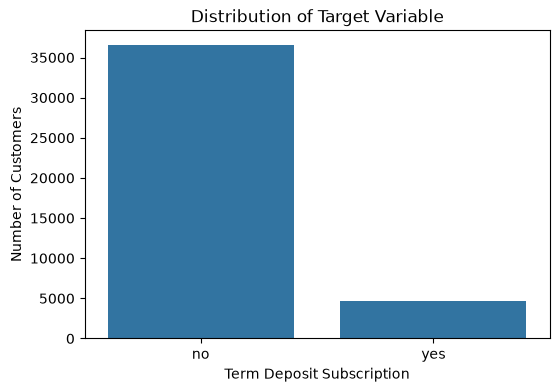

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y")

plt.title("Distribution of Target Variable")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Customers")

plt.show()

## 11. Numerical Feature Analysis

The numerical variables are analyzed using descriptive statistics.

This helps us understand the central tendency, spread, minimum and maximum values, and potential unusual observations before model development.

In [ ]:
# Display descriptive statistics for numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


In [ ]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


## 12. Categorical Feature Analysis

Categorical variables contain discrete categories such as job type, marital status, education, and contact method.

These variables cannot be directly provided to most machine learning algorithms in their original text form, so they will require appropriate encoding during preprocessing.

In [ ]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


## 13. Distribution of Numerical Features

Histograms are used to visualize the distributions of numerical variables.

These plots help identify the typical ranges, skewness, and possible extreme values in the numerical features.

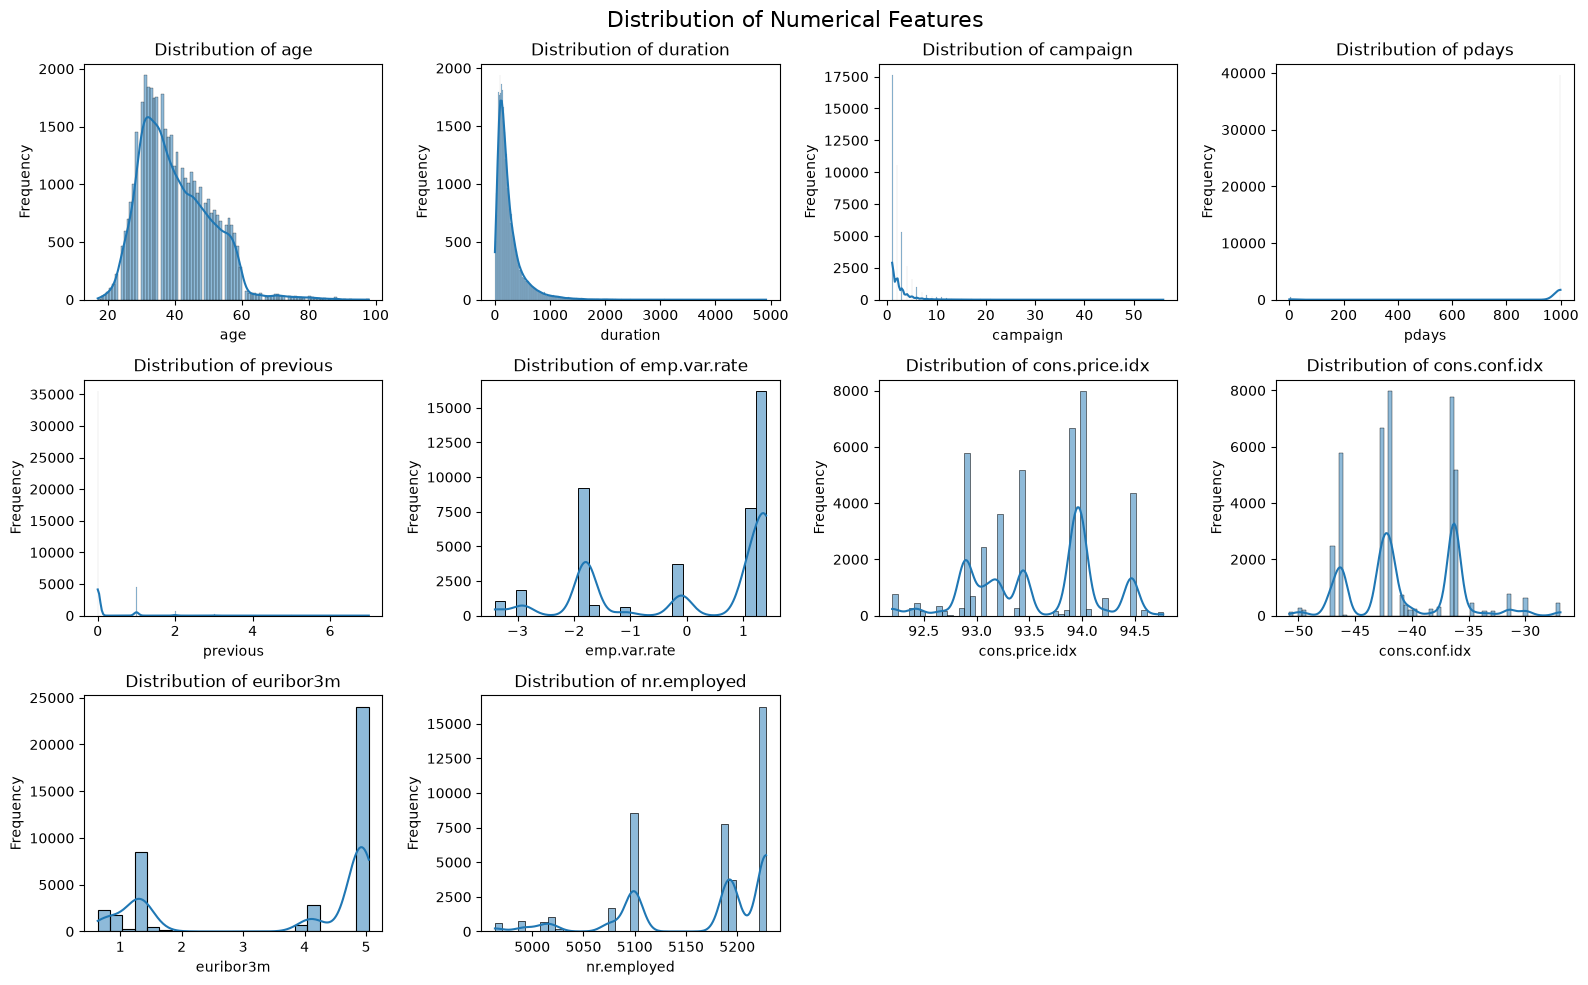

In [ ]:
# Numerical Feature Distributions

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    sns.histplot(data=df, x=column, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

# Hide unused subplot
for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## 14. Outlier Detection

Outliers are observations that are unusually far from the majority of the data.

Box plots are used to identify potential outliers in numerical variables. However, an outlier is not automatically an error, so the decision to remove or transform outliers will be based on the nature of each feature.

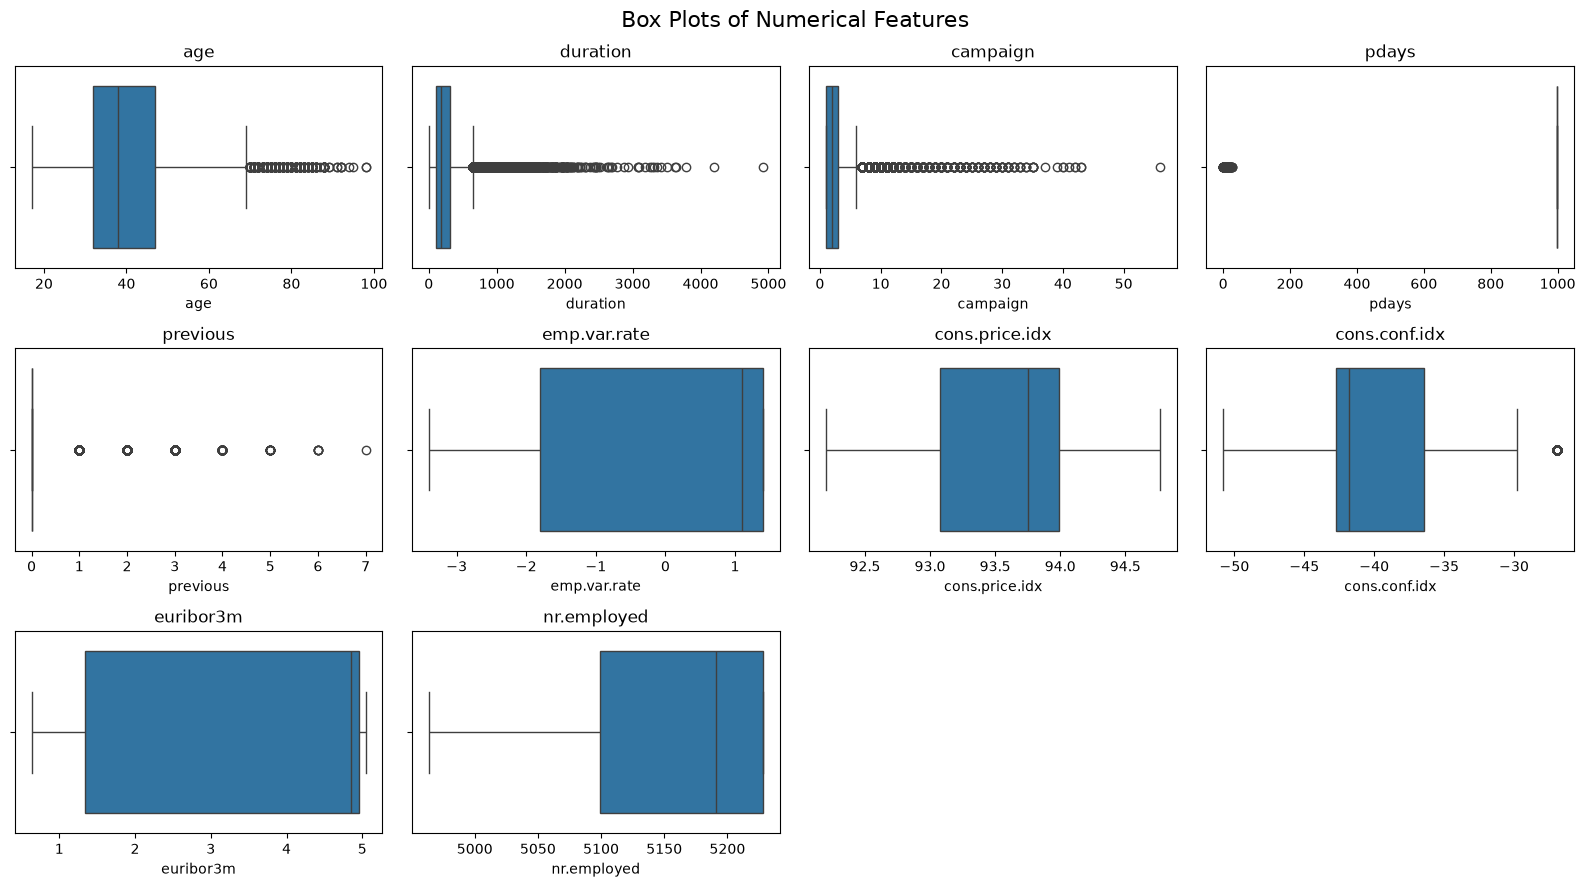

In [ ]:
# Numerical Feature Box Plots

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(column)
    axes[i].set_xlabel(column)

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box Plots of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## 15. Categorical Feature Distribution

The frequency of categories within each categorical feature is examined to understand the composition of the dataset.

This analysis is useful for identifying dominant categories, rare categories, and variables that may require special preprocessing.

In [ ]:
# Display unique categories and their counts

for column in categorical_columns.drop("y"):
    print("\n" + "=" * 50)
    print("Column:", column)
    print(df[column].value_counts())


Column: job
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Column: marital
marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64

Column: education
education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64

Column: default
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

Column: housing
housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64

Column: loan
loan
no         33938
yes         6248
unknown      9

## 16. Quantitative Outlier Analysis

The Interquartile Range (IQR) method is used to identify observations that fall outside the lower and upper bounds of a feature's typical range.

The identified values are treated as potential outliers rather than automatically removed because extreme values may represent genuine customer or campaign behavior.

In [ ]:
# Calculate potential outliers using the IQR method

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"{column}: {outliers} potential outliers")

age: 468 potential outliers
duration: 2963 potential outliers
campaign: 2406 potential outliers
pdays: 1515 potential outliers
previous: 5625 potential outliers
emp.var.rate: 0 potential outliers
cons.price.idx: 0 potential outliers
cons.conf.idx: 446 potential outliers
euribor3m: 0 potential outliers
nr.employed: 0 potential outliers


## 17. Analysis of `pdays`

The `pdays` variable represents the number of days since the customer was last contacted during a previous campaign.

The value `999` is a special encoded value indicating that the customer was not previously contacted.

Therefore, `999` should not be interpreted as literally 999 days. This characteristic is considered during exploratory data analysis and is retained as part of the original feature representation.

In [ ]:
# Check the distribution of pdays

print(df["pdays"].value_counts().sort_index())

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39661
Name: count, dtype: int64


In [ ]:
# Calculate the percentage of customers with pdays = 999

pdays_999_percentage = (df["pdays"] == 999).mean() * 100

print(f"Percentage of customers with pdays = 999: {pdays_999_percentage:.2f}%")

Percentage of customers with pdays = 999: 96.32%


## 18. Relationship Between Job and Term Deposit Subscription

The relationship between occupation and term deposit subscription is examined using the target variable `y`.

The proportion of customers who subscribed is more informative than raw counts because the number of customers in each job category differs.

In [ ]:
# Calculate subscription rate by job

job_subscription_rate = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

job_subscription_rate

y,no,yes
job,,
admin.,87.033305,12.966695
blue-collar,93.104939,6.895061
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.738068,25.261932
self-employed,89.514426,10.485574
services,91.857827,8.142173
student,68.571429,31.428571


## 19. Relationship Between Education and Term Deposit Subscription

The subscription rate is analyzed across education levels to determine whether education category is associated with differences in customer subscription behavior.

In [ ]:
education_subscription_rate = pd.crosstab(
    df["education"],
    df["y"],
    normalize="index"
) * 100

education_subscription_rate

y,no,yes
education,,
basic.4y,89.750958,10.249042
basic.6y,91.793976,8.206024
basic.9y,92.175352,7.824648
high.school,89.161060,10.838940
illiterate,77.777778,22.222222
professional.course,88.645038,11.354962
university.degree,86.279184,13.720816
unknown,85.491329,14.508671


## 20. Relationship Between Contact Type and Term Deposit Subscription

The communication method used to contact customers is compared with the target outcome.

This analysis helps determine whether the type of contact is associated with different subscription rates.

In [ ]:
contact_subscription_rate = pd.crosstab(
    df["contact"],
    df["y"],
    normalize="index"
) * 100

contact_subscription_rate

y,no,yes
contact,,
cellular,85.261144,14.738856
telephone,94.767635,5.232365


In [ ]:
# Subscription rate by previous campaign outcome

poutcome_subscription_rate = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
) * 100

print(poutcome_subscription_rate.round(2))

y               no    yes
poutcome                 
failure      85.77  14.23
nonexistent  91.17   8.83
success      34.89  65.11


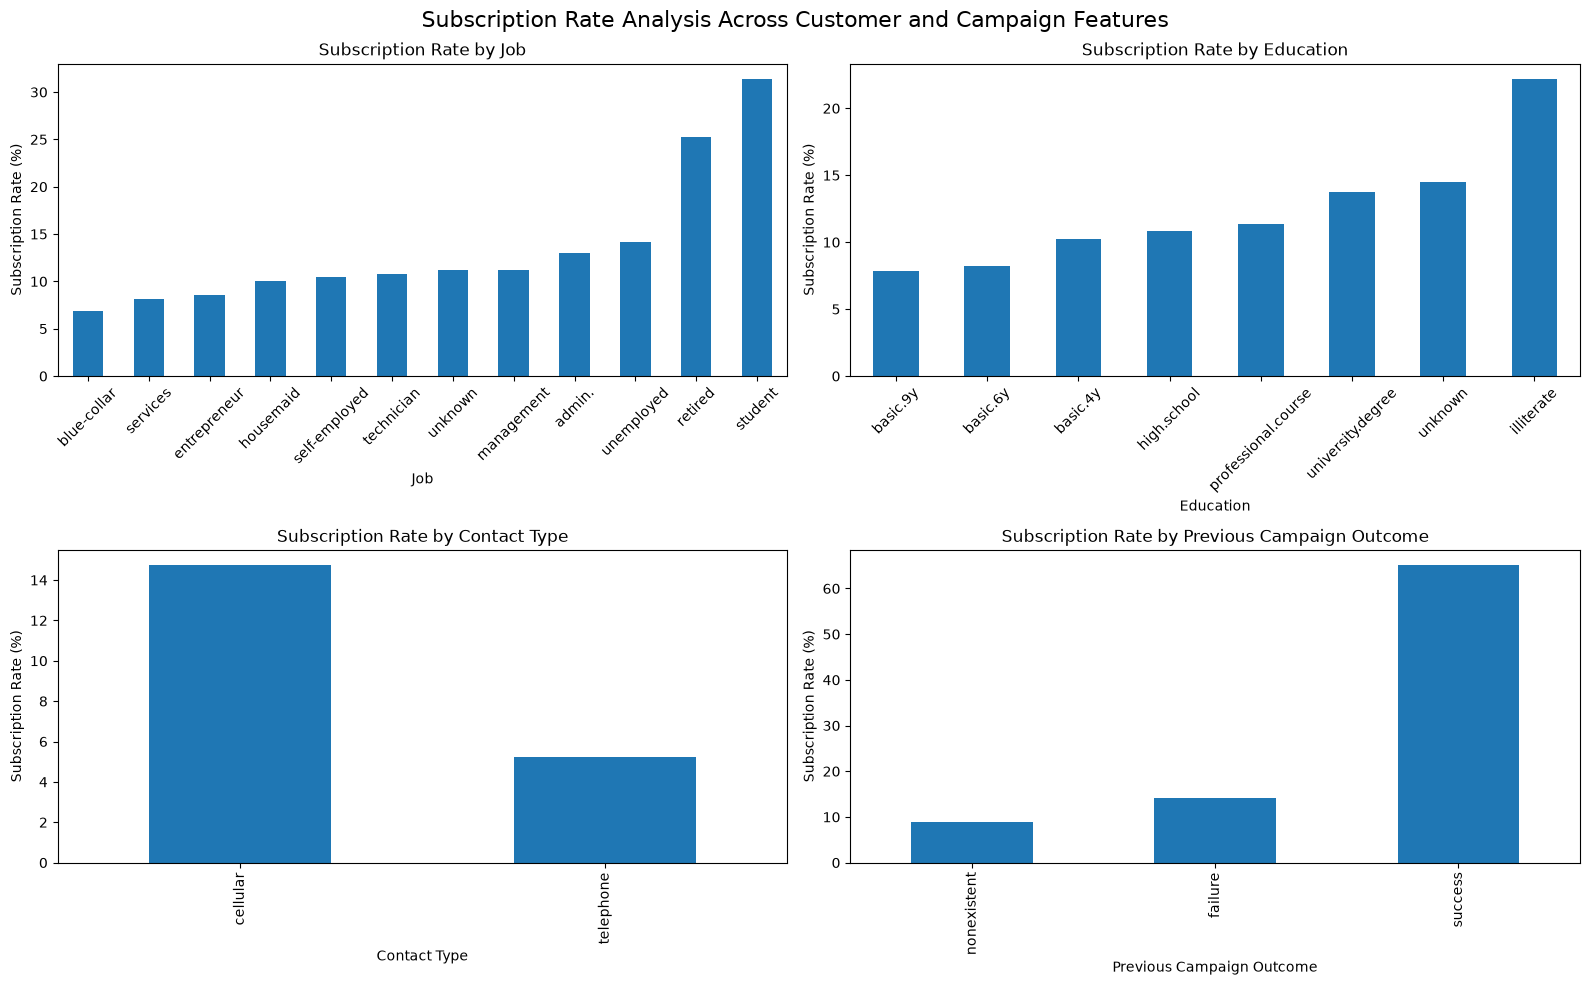

In [ ]:
# Combined Subscription Rate Analysis
# Job, Education, Contact Type and Previous Campaign Outcome

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Job
job_subscription_rate["yes"].sort_values().plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Subscription Rate by Job")
axes[0, 0].set_xlabel("Job")
axes[0, 0].set_ylabel("Subscription Rate (%)")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Education
education_subscription_rate["yes"].sort_values().plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Subscription Rate by Education")
axes[0, 1].set_xlabel("Education")
axes[0, 1].set_ylabel("Subscription Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Contact Type
contact_subscription_rate["yes"].plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Subscription Rate by Contact Type")
axes[1, 0].set_xlabel("Contact Type")
axes[1, 0].set_ylabel("Subscription Rate (%)")

# 4. Previous Campaign Outcome
poutcome_subscription_rate["yes"].sort_values().plot(
    kind="bar",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Subscription Rate by Previous Campaign Outcome")
axes[1, 1].set_xlabel("Previous Campaign Outcome")
axes[1, 1].set_ylabel("Subscription Rate (%)")

plt.suptitle(
    "Subscription Rate Analysis Across Customer and Campaign Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# Subscription rate by month

month_subscription_rate = pd.crosstab(
    df["month"],
    df["y"],
    normalize="index"
) * 100

print(month_subscription_rate.round(2))

y         no    yes
month              
apr    79.51  20.49
aug    89.39  10.61
dec    51.10  48.90
jul    90.96   9.04
jun    89.49  10.51
mar    49.45  50.55
may    93.56   6.44
nov    89.85  10.15
oct    56.07  43.93
sep    55.09  44.91


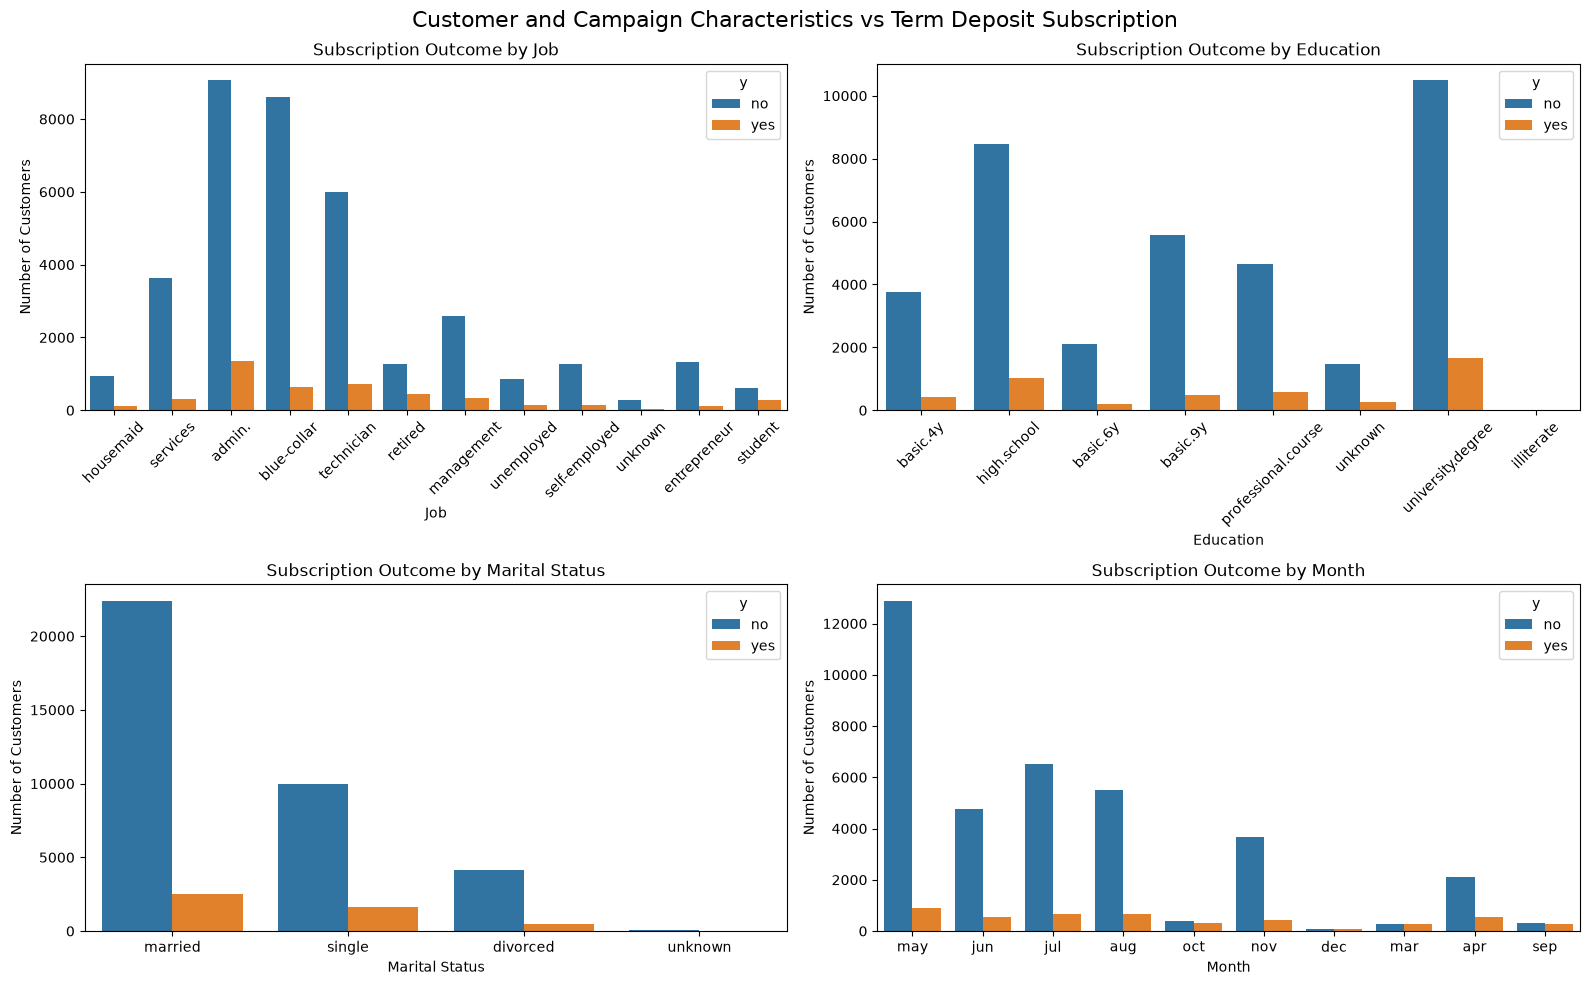

In [ ]:
# Combined Customer and Campaign Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Job vs Subscription
sns.countplot(data=df, x="job", hue="y", ax=axes[0, 0])

axes[0, 0].set_title("Subscription Outcome by Job")
axes[0, 0].set_xlabel("Job")
axes[0, 0].set_ylabel("Number of Customers")
axes[0, 0].tick_params(axis="x", rotation=45)


# 2. Education vs Subscription
sns.countplot(data=df, x="education", hue="y", ax=axes[0, 1])

axes[0, 1].set_title("Subscription Outcome by Education")
axes[0, 1].set_xlabel("Education")
axes[0, 1].set_ylabel("Number of Customers")
axes[0, 1].tick_params(axis="x", rotation=45)


# 3. Marital Status vs Subscription
sns.countplot(data=df, x="marital", hue="y", ax=axes[1, 0])

axes[1, 0].set_title("Subscription Outcome by Marital Status")
axes[1, 0].set_xlabel("Marital Status")
axes[1, 0].set_ylabel("Number of Customers")


# 4. Month vs Subscription
sns.countplot(data=df, x="month", hue="y", ax=axes[1, 1])

axes[1, 1].set_title("Subscription Outcome by Month")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Number of Customers")

plt.suptitle(
    "Customer and Campaign Characteristics vs Term Deposit Subscription",
    fontsize=16
)

plt.tight_layout()
plt.show()

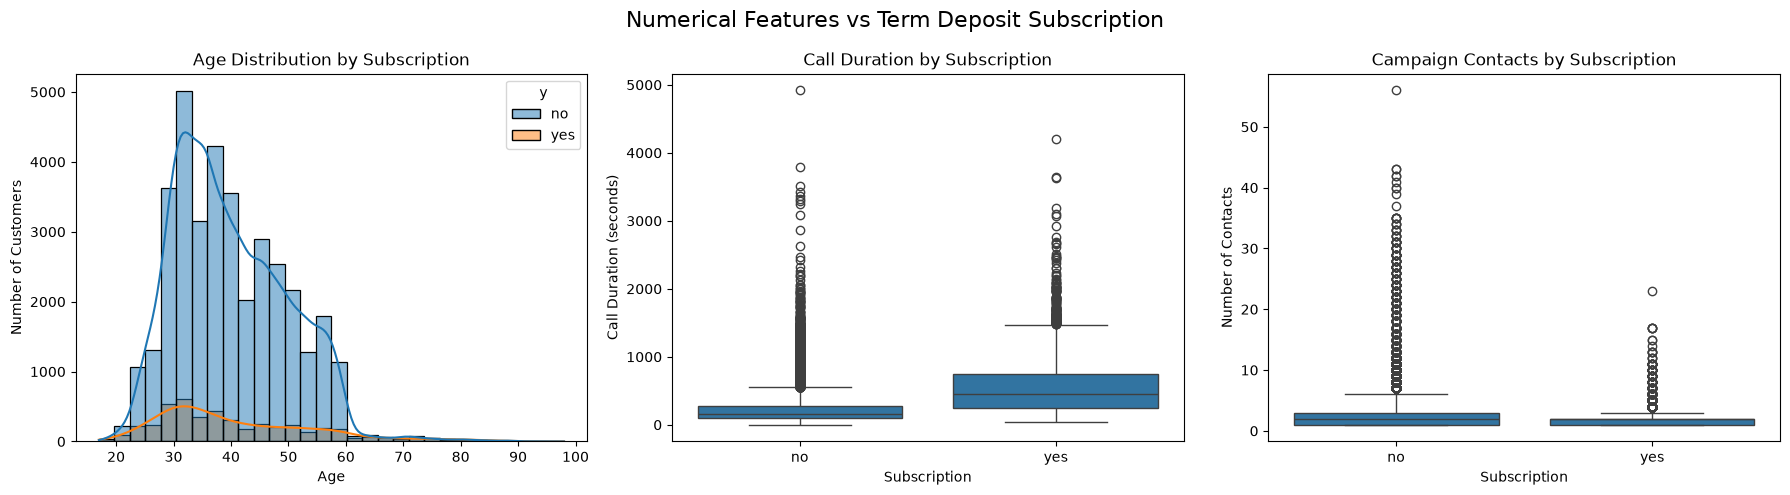

In [ ]:
# Combined Numerical Feature Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age distribution
sns.histplot(
    data=df,
    x="age",
    hue="y",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Age Distribution by Subscription")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Customers")

# 2. Call duration
sns.boxplot(
    data=df,
    x="y",
    y="duration",
    ax=axes[1]
)

axes[1].set_title("Call Duration by Subscription")
axes[1].set_xlabel("Subscription")
axes[1].set_ylabel("Call Duration (seconds)")

# 3. Campaign contacts
sns.boxplot(
    data=df,
    x="y",
    y="campaign",
    ax=axes[2]
)

axes[2].set_title("Campaign Contacts by Subscription")
axes[2].set_xlabel("Subscription")
axes[2].set_ylabel("Number of Contacts")

plt.suptitle(
    "Numerical Features vs Term Deposit Subscription",
    fontsize=16
)

plt.tight_layout()
plt.show()

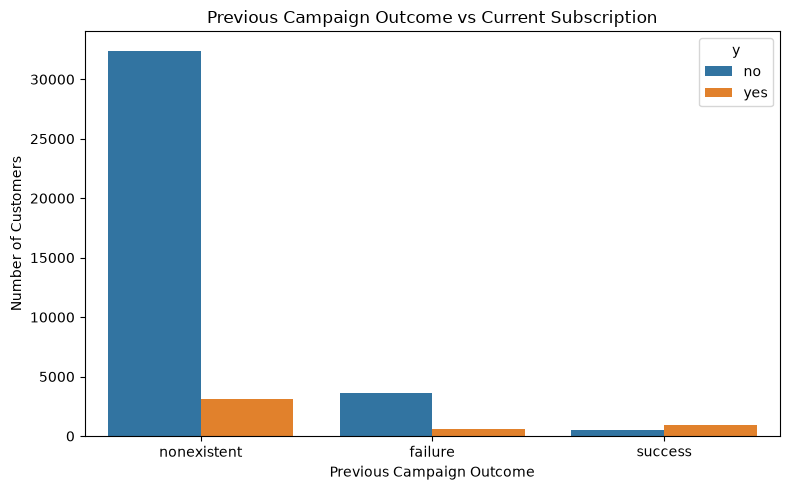

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="poutcome", hue="y")

plt.title("Previous Campaign Outcome vs Current Subscription")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

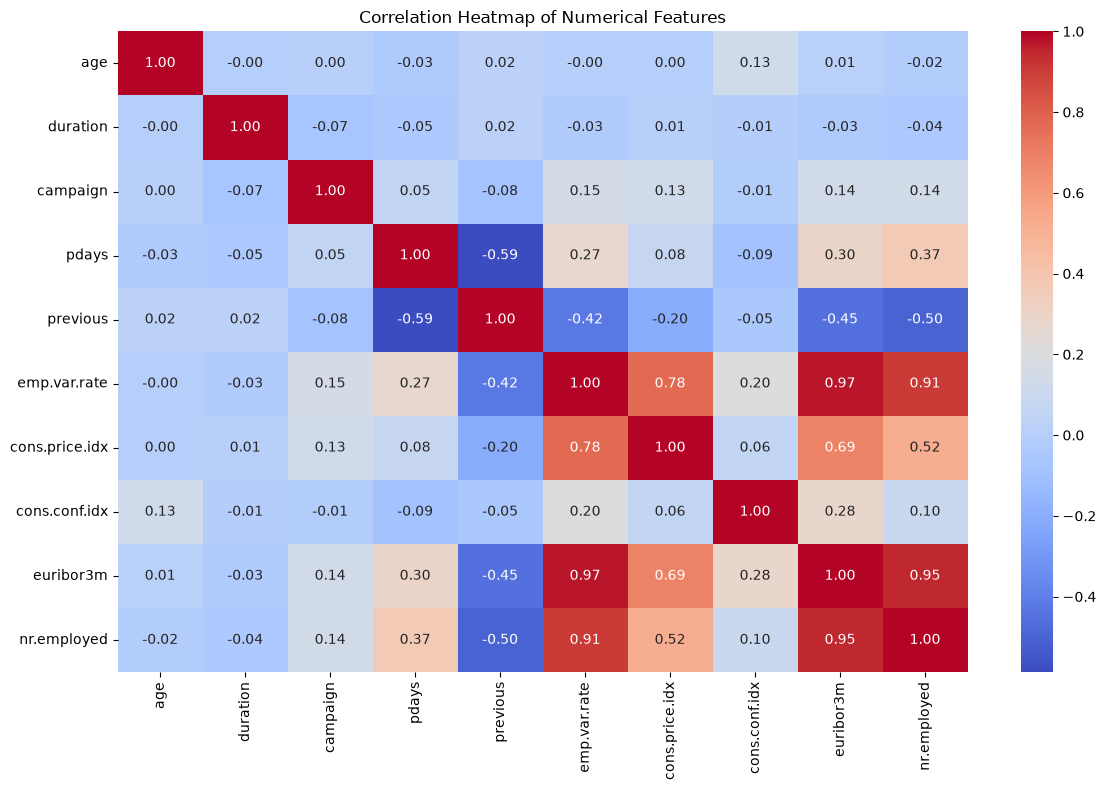

In [ ]:
# Select numerical columns
numeric_cols = df.select_dtypes(include="number").columns

# Calculate correlation
correlation = df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
# Convert target into numerical form
df["y_numeric"] = df["y"].map({"no": 0, "yes": 1})

# Correlation of numerical features with target
target_correlation = df[numeric_cols.tolist() + ["y_numeric"]].corr()["y_numeric"].sort_values(ascending=False)

print(target_correlation)

y_numeric         1.000000
duration          0.405297
previous          0.230202
cons.conf.idx     0.054802
age               0.030381
campaign         -0.066361
cons.price.idx   -0.136134
emp.var.rate     -0.298289
euribor3m        -0.307740
pdays            -0.324948
nr.employed      -0.354669
Name: y_numeric, dtype: float64


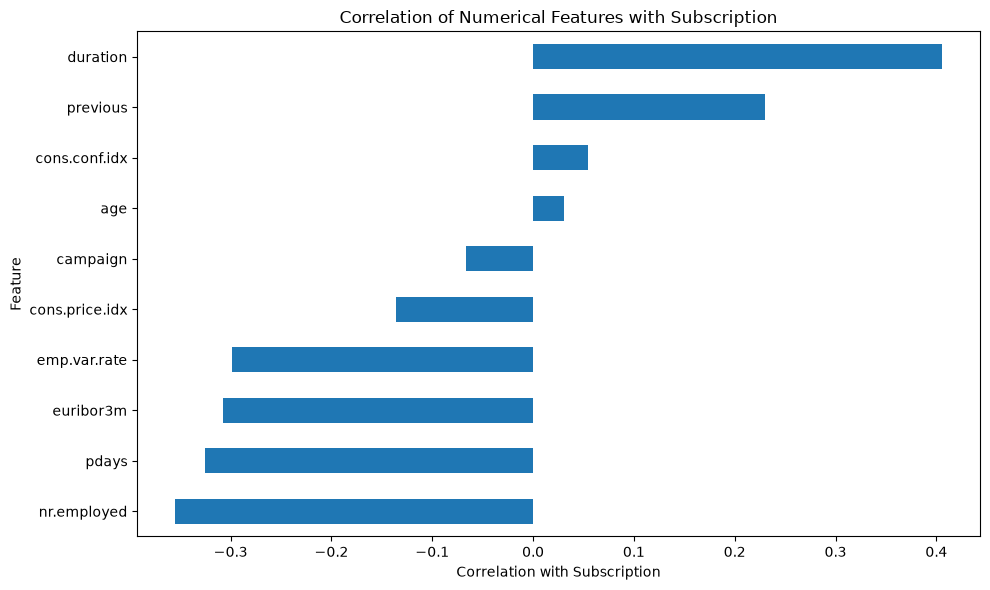

In [ ]:
plt.figure(figsize=(10, 6))

target_correlation.drop("y_numeric").sort_values().plot(kind="barh")

plt.title("Correlation of Numerical Features with Subscription")
plt.xlabel("Correlation with Subscription")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop("y_numeric", axis=1)

print("y_numeric removed successfully!")
print(df.shape)

y_numeric removed successfully!
(41176, 21)


In [ ]:
unknown_counts = (df == "unknown").sum()

print("Unknown values in each column:")
print(unknown_counts[unknown_counts > 0])

Unknown values in each column:
job           330
marital        80
education    1730
default      8596
housing       990
loan          990
dtype: int64


In [ ]:
df["y"] = df["y"].map({"no": 0, "yes": 1})

print(df["y"].value_counts())

y
0    36537
1     4639
Name: count, dtype: int64


In [ ]:
X = df.drop("y", axis=1)
y = df["y"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (41176, 20)
Target shape: (41176,)


In [ ]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(include="number").columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [ ]:
X = X.drop("duration", axis=1)

print("Duration removed.")
print("New feature shape:", X.shape)

Duration removed.
New feature shape: (41176, 19)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (32940, 19)
Testing features shape: (8236, 19)
Training target shape: (32940,)
Testing target shape: (8236,)


In [ ]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
y
0    0.887341
1    0.112659
Name: proportion, dtype: float64

Testing target distribution:
y
0    0.887324
1    0.112676
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

print("Encoded training categorical shape:", X_train_encoded.shape)
print("Encoded testing categorical shape:", X_test_encoded.shape)

Encoded training categorical shape: (32940, 53)
Encoded testing categorical shape: (8236, 53)


In [ ]:
numerical_cols = X.select_dtypes(include="number").columns.tolist()

print("Numerical columns:")
print(numerical_cols)
print("Number of numerical features:", len(numerical_cols))

Numerical columns:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Number of numerical features: 9


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

print("Scaled training numerical shape:", X_train_num.shape)
print("Scaled testing numerical shape:", X_test_num.shape)

Scaled training numerical shape: (32940, 9)
Scaled testing numerical shape: (8236, 9)


In [ ]:
import numpy as np

X_train_final = np.hstack([X_train_num, X_train_encoded])
X_test_final = np.hstack([X_test_num, X_test_encoded])

print("Final training feature shape:", X_train_final.shape)
print("Final testing feature shape:", X_test_final.shape)

Final training feature shape: (32940, 62)
Final testing feature shape: (8236, 62)


In [ ]:
# Target variable

y = df['y']

print("Target variable:")
print(y.value_counts())

Target variable:
y
0    36537
1     4639
Name: count, dtype: int64


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (32940, 19)
X_test shape: (8236, 19)


In [ ]:
print(df['y'].unique())
print(df['y'].value_counts(dropna=False))

[0 1]
y
0    36537
1     4639
Name: count, dtype: int64


In [ ]:
print("Variables containing 'train':")

for name in dir():
    if 'train' in name.lower():
        print(name)

Variables containing 'train':
X_train
X_train_encoded
X_train_final
X_train_num
train_test_split
y_train


In [ ]:
print("\nVariables containing 'test':")

for name in dir():
    if 'test' in name.lower():
        print(name)


Variables containing 'test':
X_test
X_test_encoded
X_test_final
X_test_num
train_test_split
y_test


In [ ]:
print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (32940, 62)
Final testing shape: (8236, 62)


In [ ]:
# Use the final encoded features for model building

X_train = X_train_final
X_test = X_test_final

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (32940, 62)
X_test shape: (8236, 62)


In [ ]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

y_train shape: (32940,)
y_test shape: (8236,)

y_train distribution:
y
0    29229
1     3711
Name: count, dtype: int64

y_test distribution:
y
0    7308
1     928
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [ ]:
# Train Logistic Regression model

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test data

y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred_logistic[:20])

Predictions generated successfully!
First 20 predictions:
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Logistic Regression Results
---------------------------
Accuracy : 0.898251578436134
Precision: 0.65
Recall   : 0.2101293103448276
F1-Score : 0.31758957654723124


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7203  105]
 [ 733  195]]


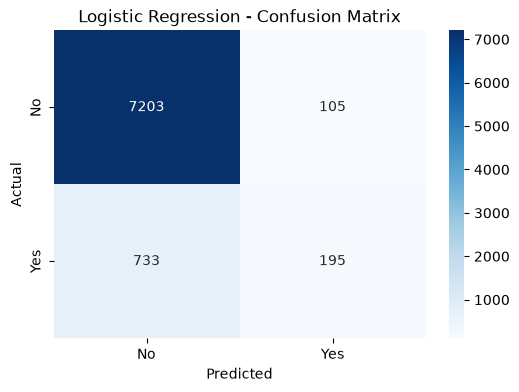

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability of the positive class (Yes)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression ROC-AUC:", roc_auc)

Logistic Regression ROC-AUC: 0.8004347355519695


In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve for Logistic Regression

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_logistic
)

print("Logistic Regression ROC curve calculated successfully!")

Logistic Regression ROC curve calculated successfully!


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
dt_model.fit(X_train_final, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# Make predictions using Decision Tree
y_pred_dt = dt_model.predict(X_test_final)

print("Decision Tree predictions generated successfully!")
print("First 20 predictions:")
print(y_pred_dt[:20])

Decision Tree predictions generated successfully!
First 20 predictions:
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("## Decision Tree Results")
print()
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1-Score :", f1_dt)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print()
print("Confusion Matrix:")
print(cm_dt)

## Decision Tree Results

Accuracy : 0.9009227780475959
Precision: 0.6521739130434783
Recall   : 0.25862068965517243
F1-Score : 0.37037037037037035

Confusion Matrix:
[[7180  128]
 [ 688  240]]


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probability predictions
y_prob_dt = dt_model.predict_proba(X_test_final)[:, 1]

# Calculate ROC-AUC
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", roc_auc_dt)

# Calculate ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)


Decision Tree ROC-AUC: 0.7910203066313722


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_final, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Make predictions using Random Forest
y_pred_rf = rf_model.predict(X_test_final)

print("Random Forest predictions generated successfully!")
print("First 20 predictions:")
print(y_pred_rf[:20])

Random Forest predictions generated successfully!
First 20 predictions:
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get probability predictions
y_prob_rf = rf_model.predict_proba(X_test_final)[:, 1]

# Calculate ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

# Calculate ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

Random Forest ROC-AUC: 0.8093396407810053


In [ ]:
# Check shapes of numeric and encoded parts

print("X_train_num shape:", X_train_num.shape)
print("X_train_encoded shape:", X_train_encoded.shape)
print("RF features:", len(rf_model.feature_importances_))

X_train_num shape: (32940, 9)
X_train_encoded shape: (32940, 53)
RF features: 62


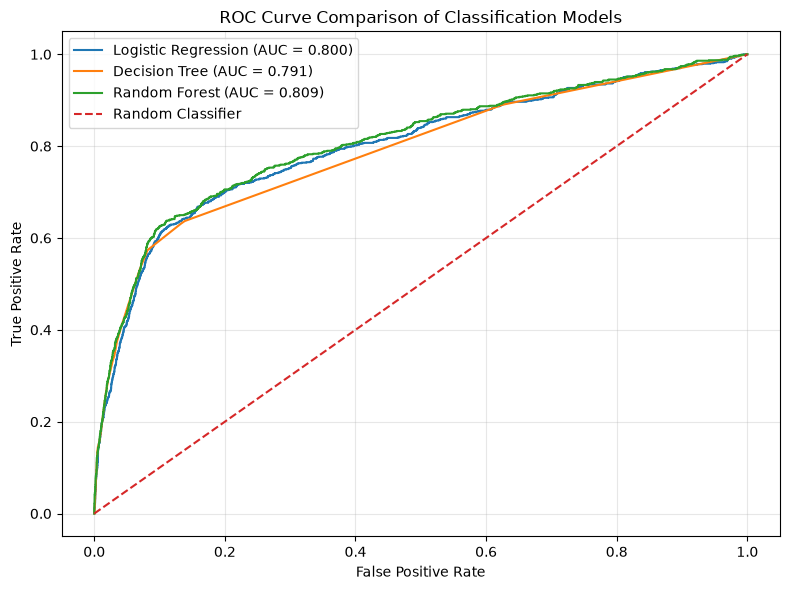

In [ ]:
# Combined ROC Curve for All Models

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_dt:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("## Random Forest Results")
print()
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-Score :", f1_rf)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print()
print("Confusion Matrix:")
print(cm_rf)

## Random Forest Results

Accuracy : 0.8999514327343371
Precision: 0.667741935483871
Recall   : 0.22306034482758622
F1-Score : 0.3344103392568659

Confusion Matrix:
[[7205  103]
 [ 721  207]]


In [ ]:
# Numeric feature names
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target column if present
numeric_features.remove('y') if 'y' in numeric_features else None

print("Numeric features:")
print(numeric_features)
print("Count:", len(numeric_features))

Numeric features:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Count: 9


In [ ]:
# Get encoded feature names from OneHotEncoder

categorical_features = X.select_dtypes(include=['object']).columns

encoded_features = encoder.get_feature_names_out(categorical_features)

print("Encoded features count:", len(encoded_features))

Encoded features count: 53


In [ ]:
# Combine all feature names

feature_names = numeric_features + list(encoded_features)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
8,nr.employed,0.146098
7,euribor3m,0.144531
61,poutcome_success,0.089005
2,pdays,0.086525
4,emp.var.rate,0.080940
6,cons.conf.idx,0.061817
5,cons.price.idx,0.047237
0,age,0.041919
3,previous,0.025581
1,campaign,0.017304


In [ ]:
# Model comparison table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_dt,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.898252,0.650000,0.210129,0.31759,0.800435
1,Decision Tree,0.900923,0.652174,0.258621,0.37037,0.791020
2,Random Forest,0.899951,0.667742,0.223060,0.33441,0.809340


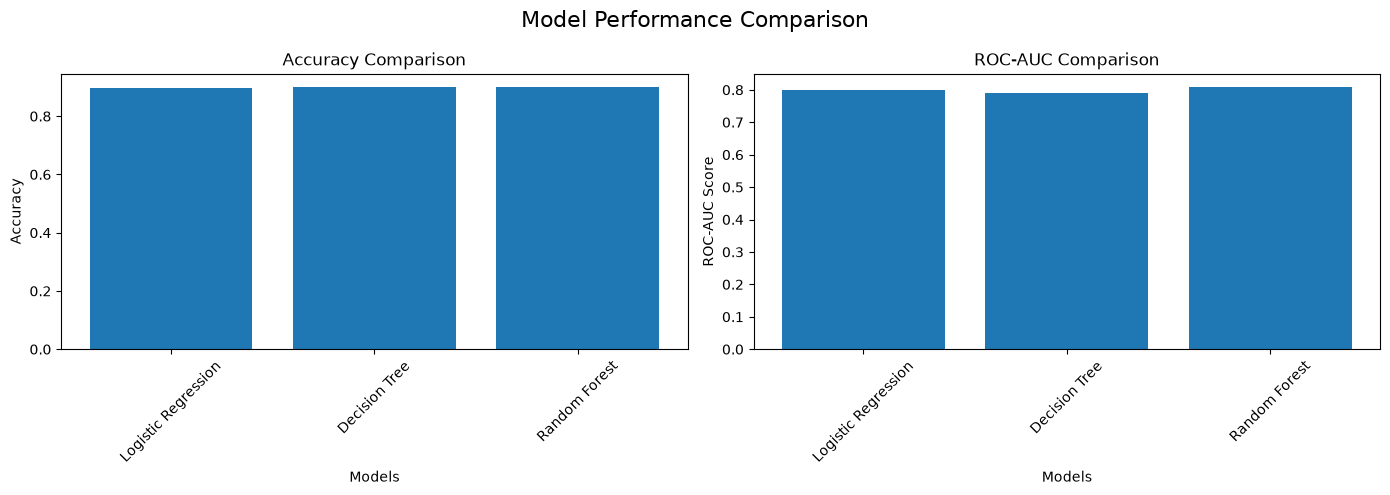

In [ ]:
# Model Performance Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Accuracy Comparison
axes[0].bar(results["Model"], results["Accuracy"])
axes[0].set_title("Accuracy Comparison")
axes[0].set_xlabel("Models")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=45)

# 2. ROC-AUC Comparison
axes[1].bar(results["Model"], results["ROC-AUC"])
axes[1].set_title("ROC-AUC Comparison")
axes[1].set_xlabel("Models")
axes[1].set_ylabel("ROC-AUC Score")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import joblib

PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(rf_model, MODEL_DIR / "random_forest_model.pkl")
joblib.dump(encoder, MODEL_DIR / "encoder.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
print("Random Forest model and encoder saved successfully!")
print("Scaler saved successfully!")

Random Forest model and encoder saved successfully!
Scaler saved successfully!


In [ ]:
import os
print(os.getcwd())

/Users/bhavyasreekotha/Desktop/Bank_Marketing_ML_Project/notebooks


In [ ]:
# Taking one sample from test data

sample = X_test_final[0].reshape(1, -1)

prediction = rf_model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


#  Conclusion

This project developed an end-to-end machine learning classification system to predict whether a customer would subscribe to a bank term deposit using the Bank Marketing dataset.

The project included data loading, data quality checking, duplicate removal, exploratory data analysis, handling of categorical variables, target encoding, feature preprocessing, train-test splitting, one-hot encoding, feature scaling, and model development.

Three classification algorithms were implemented and compared:
- Logistic Regression
- Decision Tree
- Random Forest

The models were evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, confusion matrices, and ROC curves. The evaluation results provide a comparison of the models and help identify the most suitable model for predicting term-deposit subscriptions.

The analysis also showed that the target variable is imbalanced, with customers who did not subscribe being much more common than customers who subscribed. Therefore, accuracy alone is not sufficient for evaluating the models, and metrics such as Recall, F1-Score, and ROC-AUC are also considered.

The `duration` feature was excluded from model training because it represents the duration of the current call and would only be known after or during the campaign interaction. Removing it makes the prediction more appropriate for a realistic pre-contact prediction scenario.

The final Random Forest model, encoder, and scaler were saved for future use. Predictions and evaluation results were generated during the project for model assessment.

Overall, this project demonstrates a complete machine learning workflow, from raw customer data analysis to preprocessing, model training, evaluation, comparison, and prediction.